<a href="https://colab.research.google.com/github/Aisha037922/retail-sales-trends-and-promotion-impact-analysis/blob/main/warehouse__Retail_Sales_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Warehouse and Retail Sales Analysis

This project presents an **Exploratory Data Analysis (EDA)** and **Data Visualization** of sales data from both **retail** and **warehouse** channels for **wine and beer products**, using Python.

---

### 📌 About the Project

The goal of this project is to analyze differences in sales performance across various suppliers by comparing their **retail sales** and **warehouse sales**. It also aims to uncover trends, patterns, and insights within the sales data to better understand supplier performance and support data-driven decision-making.

---

### 🛠️ Technologies & Tools Used

- **Programming Language:**
  - Python

- **Libraries:**
  - `Pandas` – data manipulation and analysis  
  - `NumPy` – numerical operations  
  - `Matplotlib` – data visualization

- **Techniques:**
  - Exploratory Data Analysis (EDA)  
  - Basic Statistical Analysis  
  - Data Visualization

---
### 🧼 Data Cleaning

- Loaded the dataset using `pandas`.
- Removed rows with missing values using `dropna()`.
- Verified that no null values remained using `isnull().sum()`.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Importing the data
data = pd.read_csv("Warehouse_and_Retail_Sales.csv")
data.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [ ]:
# Remove rows that are null/ Missing data
data = data.dropna(axis=0)
data.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [ ]:
# Identify missing values with in the data
data.isnull().sum()

YEAR                0
MONTH               0
SUPPLIER            0
ITEM CODE           0
ITEM DESCRIPTION    0
ITEM TYPE           0
RETAIL SALES        0
RETAIL TRANSFERS    0
WAREHOUSE SALES     0
dtype: int64

### 1. 📈 Sales Trends Over Time
**Goal**: Identify patterns or seasonality in sales across time.

**Key Questions**:
- How do sales vary by **month or year**?
- Are there **seasonal spikes** (e.g. holidays)?
- How has **total sales volume** changed over time?

**Approach**:
- Aggregate `RETAIL SALES` and `WAREHOUSE SALES` by month/year.
- Visualize using line charts or seasonal decomposition.

In [ ]:
# Aggregate data across all numeric collums
data.select_dtypes(include='number').aggregate(['sum', 'min'])

,YEAR,MONTH,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
sum,620623334,1975252,2153459.39,2133329.71,7802401.28
min,2017,1,-6.49,-38.49,-4996.00


In [ ]:
# Aggregate by Year: Sales summary by Year
yearly_sales_summary = data.groupby('YEAR').agg({
"RETAIL SALES":['sum', 'min'],
"WAREHOUSE SALES":['sum', 'min'],
})
yearly_sales_summary.head()

RETAIL SALES       WAREHOUSE SALES        
              sum   min             sum     min
YEAR                                           
2017    686734.57 -6.49      2340495.13 -4996.0
2018    153595.90 -0.58       519748.19 -4302.0
2019    958179.83 -1.17      3555701.23 -4365.0
2020    354949.09 -0.42      1386456.73 -3999.0

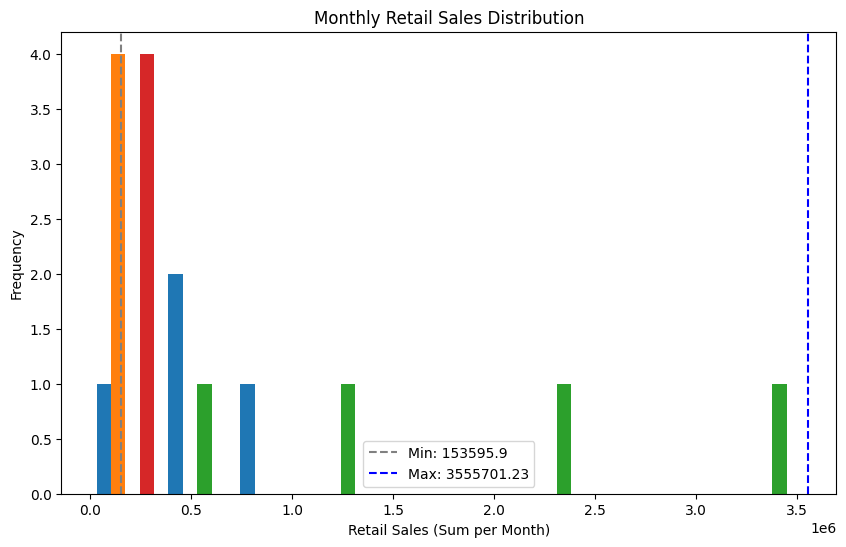

In [ ]:
# Ploting for Monthly Sales summmary
fig = plt.figure(figsize=(10,6))
plt.hist(yearly_sales_summary)

min_value = yearly_sales_summary[('RETAIL SALES', 'sum')].min()
max_value = yearly_sales_summary[('WAREHOUSE SALES', 'sum')].max()
plt.axvline(x=min_value, color="gray", linestyle="--", label=f"Min: {min_value}")
plt.axvline(x=max_value, color="blue", linestyle="--", label=f"Max: {max_value}")

# Labels and title
plt.title("Monthly Retail Sales Distribution")
plt.xlabel("Retail Sales (Sum per Month)")
plt.ylabel("Frequency")
plt.legend()

# Show the plot
plt.show()


In [ ]:
# Aggregate by Month: Sale summary by Month
monthly_sales_summary = data.groupby('MONTH').agg({
"RETAIL SALES":['sum', 'min'],
"WAREHOUSE SALES":['sum', 'min'],
})
monthly_sales_summary.head()

RETAIL SALES       WAREHOUSE SALES        
               sum   min             sum     min
MONTH                                           
1        225603.05 -0.58       821576.63 -4302.0
2        157898.62 -0.83       514326.20 -3666.0
3        193225.27 -0.17       611272.70 -3983.0
4         80320.72 -0.17       299310.87 -4299.0
5         94921.74 -0.33       383857.58 -4155.0

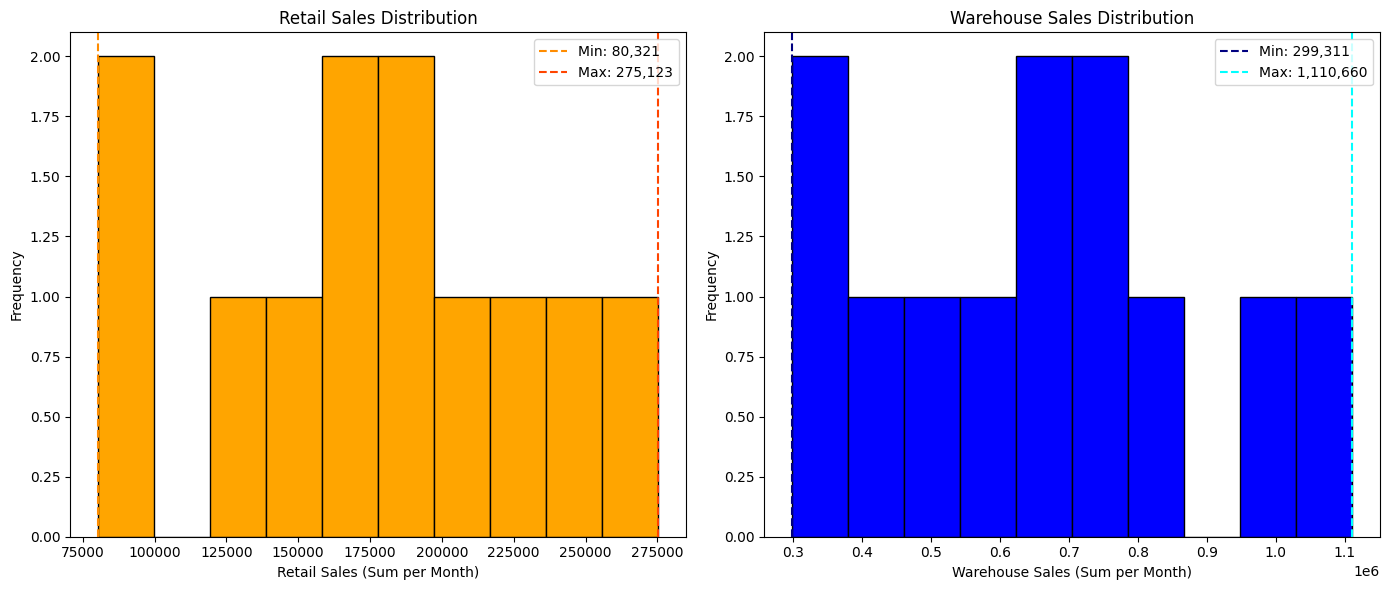

In [ ]:
import matplotlib.pyplot as plt

# Extract sales data
retail_sales = monthly_sales_summary[('RETAIL SALES', 'sum')]
warehouse_sales = monthly_sales_summary[('WAREHOUSE SALES', 'sum')]

# Create 1 row, 2 columns subplot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Retail Sales histogram on first subplot
axes[0].hist(retail_sales, bins=10, color='orange', edgecolor='black')
axes[0].axvline(retail_sales.min(), color="darkorange", linestyle="--", label=f"Min: {retail_sales.min():,.0f}")
axes[0].axvline(retail_sales.max(), color="orangered", linestyle="--", label=f"Max: {retail_sales.max():,.0f}")
axes[0].set_title("Retail Sales Distribution")
axes[0].set_xlabel("Retail Sales (Sum per Month)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Plot Warehouse Sales histogram on second subplot
axes[1].hist(warehouse_sales, bins=10, color='blue', edgecolor='black')
axes[1].axvline(warehouse_sales.min(), color="navy", linestyle="--", label=f"Min: {warehouse_sales.min():,.0f}")
axes[1].axvline(warehouse_sales.max(), color="cyan", linestyle="--", label=f"Max: {warehouse_sales.max():,.0f}")
axes[1].set_title("Warehouse Sales Distribution")
axes[1].set_xlabel("Warehouse Sales (Sum per Month)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# Adjust layout and show plot
plt.tight_layout()
plt.show()




### 2. 🚚 Supplier Performance Analysis
**Goal**: Evaluate which suppliers drive the most sales.

**Key Questions**:
- Who are the **top suppliers** by total sales?
- Which suppliers show the **highest growth or decline**?

**Approach**:
- Group by `SUPPLIER`, sum up sales.
- Rank and visualize top performers using bar charts.

In [ ]:
## Who are the top suppliers by total sales?

# 1. Create a new collumn tittle 'Total Sales' combinese the sales
data["Total Sales"] = data['RETAIL SALES'] + data['WAREHOUSE SALES']

# 2. Group by supplier and the sum of Total Sales.
top_suppliers = data.groupby('SUPPLIER')['Total Sales'].sum().reset_index()

# 3. Sort by total sales in descending order
top_suppliers_sorted = top_suppliers.sort_values(by='Total Sales', ascending=False)
print(top_suppliers_sorted)

                     SUPPLIER  Total Sales
81              CROWN IMPORTS   1736309.17
214    MILLER BREWING COMPANY   1512585.15
15         ANHEUSER BUSCH INC   1441131.66
158              HEINEKEN USA    885936.37
108        E & J GALLO WINERY    363634.31
..                        ...          ...
336   THE DOG BEVERAGE CO INC         0.04
244    PACIFIC RIM WINEMAKERS         0.00
154                  HAMCO DC         0.00
177    KAHN PAPER COMPANY INC         0.00
258  PREMIUM DISTRIBUTORS INC    -53782.00

[396 rows x 2 columns]


In [ ]:
# Sort the data by supplier name in ascending order (A to Z)
data = data.sort_values('SUPPLIER', ascending=True)
data.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES,Total Sales
80361,2017,9,8 VINI INC,331348,SECOLI RIPASSO DELIO VAL DOC - 750ML,WINE,0.08,0.0,0.0,0.08
136181,2018,1,8 VINI INC,331348,SECOLI RIPASSO DELIO VAL DOC - 750ML,WINE,0.24,0.0,0.0,0.24
93633,2017,10,8 VINI INC,328382,REGGIANO MEDERFIL LAMB - 750ML,WINE,0.00,0.0,1.0,1.00
93840,2017,10,8 VINI INC,331348,SECOLI RIPASSO DELIO VAL DOC - 750ML,WINE,0.16,2.0,0.0,0.16
66883,2017,8,8 VINI INC,331348,SECOLI RIPASSO DELIO VAL DOC - 750ML,WINE,0.24,0.0,0.0,0.24


In [ ]:
# 1.Which supplier shows the highest growth in retail sales?
highest_growth = data['RETAIL SALES'].max()
data_highest_growth = data.loc[data['RETAIL SALES'] == highest_growth, 'SUPPLIER'].iloc[0]

# 2. Which supplier shows the lowest growth in retail sales?
highest_decline = data['RETAIL SALES'].min()
data_highest_decline = data.loc[data['RETAIL SALES'] == highest_decline, 'SUPPLIER'].iloc[0]

# Print the results
print(f"Highest growth: {highest_growth:}")
print(f"Highest decline: {highest_decline:}")

Highest growth: 1816.49
Highest decline: -6.49


In [ ]:
# Calculate percent share of total sales per supplier
total_all_suppliers = data['Total Sales'].sum()

# Calculate each supplier's sales as a percent of total
data['PERCENT SHARE'] = (data['Total Sales']/ total_all_suppliers) * 100

print(data[['SUPPLIER', 'Total Sales', 'PERCENT SHARE']])

          SUPPLIER  Total Sales  PERCENT SHARE
80361   8 VINI INC         0.08   8.035468e-07
136181  8 VINI INC         0.24   2.410640e-06
93633   8 VINI INC         1.00   1.004434e-05
93840   8 VINI INC         0.16   1.607094e-06
66883   8 VINI INC         0.24   2.410640e-06
...            ...          ...            ...
184901  ZURENA LLC         0.90   9.039902e-06
91493   ZURENA LLC         0.97   9.743005e-06
197627  ZURENA LLC         0.57   5.725271e-06
2702    ZURENA LLC         4.42   4.439596e-05
210458  ZURENA LLC         0.41   4.118177e-06

[307477 rows x 3 columns]


### 4. 🔄 Inventory Movement Analysis
**Goal**: Understand how products move from warehouse to retail.

**Key Questions**:
- Is there a relationship between **warehouse sales** and **retail transfers**?
- Are items being transferred but **not sold**?

**Approach**:
- Calculate correlations between warehouse and retail data.
- Detect anomalies like high transfers with zero sales.


In [ ]:
# Calculate corealtion between Warehouse and retail sales
correlation = data['RETAIL SALES'].corr(data['WAREHOUSE SALES'])
print(f"Correlation between Retail and Warehouse Sales: {correlation:.2f}")

Correlation between Retail and Warehouse Sales: 0.50


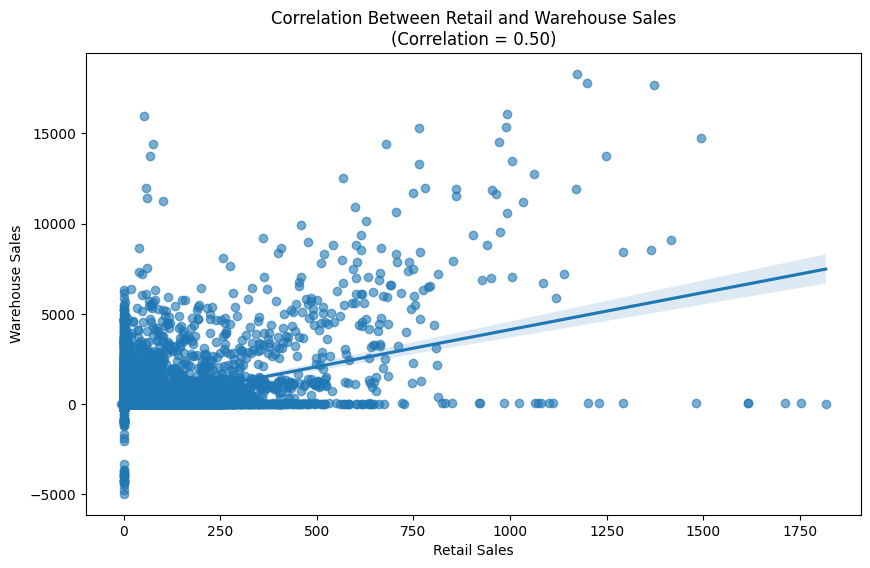

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting
plt.figure(figsize=(10, 6))
sns.regplot(x='RETAIL SALES', y='WAREHOUSE SALES', data=data, scatter_kws={'alpha':0.6})
plt.title(f'Correlation Between Retail and Warehouse Sales\n(Correlation = {correlation:.2f})')
plt.xlabel('Retail Sales')
plt.ylabel('Warehouse Sales')
plt.show()

In [ ]:
# Is there a correlation between item type and retail transfers
# Calculate the average (mean), median, or distribution of RETAIL TRANSFERS for each ITEM TYPE
grouped_corr = data.groupby('ITEM TYPE')['RETAIL TRANSFERS'].describe()
print(grouped_corr)

                 count       mean        std    min  25%   50%   75%      max
ITEM TYPE                                                                    
BEER           42413.0  13.361799  56.757857 -23.00  0.0   0.0   4.0  1462.00
DUNNAGE           72.0   0.000000   0.000000   0.00  0.0   0.0   0.0     0.00
KEGS           10146.0  -0.000099   0.009928  -1.00  0.0   0.0   0.0     0.00
LIQUOR         64910.0  12.243656  39.341262 -38.49  0.0   1.0  10.0  1990.83
NON-ALCOHOL     1899.0  14.042328  27.128881  -2.00  0.0   5.0  17.0   308.92
REF               79.0   4.923038   9.409718  -0.08  0.0   0.0   8.5    49.00
STR_SUPPLIES     318.0  32.099560  45.173980   0.00  0.0  18.0  44.0   428.00
WINE          187640.0   3.915040  13.857081  -8.67  0.0   0.0   1.0   841.00


<function matplotlib.pyplot.show(close=None, block=None)>

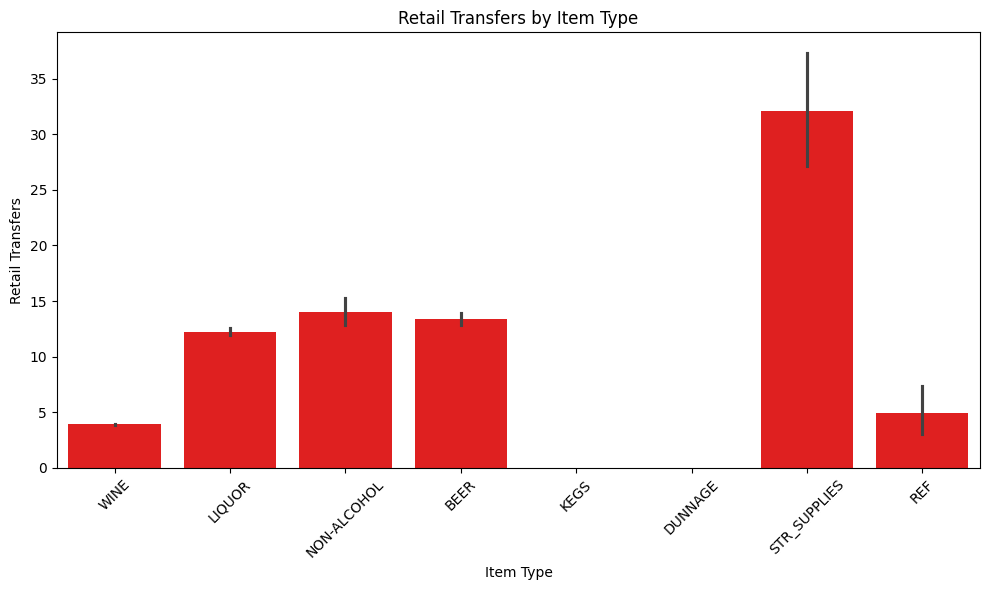

In [ ]:
# Box plot that visualises the correlation betwwen iteam and retail transfers
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(x='ITEM TYPE', y='RETAIL TRANSFERS', data=data, color='red')
plt.title('Retail Transfers by Item Type')
plt.xlabel('Item Type')
plt.ylabel('Retail Transfers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

In [ ]:
# Define transfer threshold as the 75th percentile
transfer_threshold = data['RETAIL TRANSFERS'].quantile(0.75)

# high transfers and zero sales
anomalies = data[(data['RETAIL TRANSFERS'] > transfer_threshold) & (data['RETAIL SALES'] == 0)]

# Display the anomalies
anomalies.head()


,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES,Total Sales,PERCENT SHARE
133623,2018,1,ANHEUSER BUSCH INC,28493,BUD LIGHT 3/8PK 16OZ CALNR - 16OZ,BEER,0.0,6.0,316.33,316.33,0.003177
298757,2020,9,ANHEUSER BUSCH INC,26207,DEVILS BACKBONE O'FEST 4/6NR - 12OZ,BEER,0.0,18.0,175.75,175.75,0.001765
90855,2017,10,ANHEUSER BUSCH INC,26334,SHOCK TOP WINTER SAMPLER 12PK NR,BEER,0.0,6.0,180.00,180.00,0.001808
97885,2017,10,ANHEUSER BUSCH INC,48983,BUDWEISER 1933 REPEAL LGR 4/6 NR,BEER,0.0,5.0,338.00,338.00,0.003395
97884,2017,10,ANHEUSER BUSCH INC,48977,STELLA ARTOIS 18PK 11.2OZ NR,BEER,0.0,4.0,246.00,246.00,0.002471
